In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

In [2]:
iris = load_iris()

print(type(iris))

<class 'sklearn.utils._bunch.Bunch'>


In [3]:
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [4]:
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")

In [5]:
print(X.head())
print()
print(y.head())
print()
print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("Target names:", iris.target_names)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

X shape: (150, 4)
y shape: (150,)

Target names: ['setosa' 'versicolor' 'virginica']


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Structural Integrity: The Split (80% Train, 20% Test)
# random_state ensures reproducibility. We shuffle to remove order bias.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# 2. The Gatekeeper: Feature Scaling
scaler = StandardScaler()

# Fit on training data AND transform it
X_train_scaled = scaler.fit_transform(X_train)

# ONLY transform testing data (Never fit the scaler on test data to avoid data leakage)
X_test_scaled = scaler.transform(X_test)

print("\nScaling complete. Mean of scaled train features:", X_train_scaled.mean(axis=0).round(2))

Training data shape: (120, 4)
Testing data shape: (30, 4)

Scaling complete. Mean of scaled train features: [ 0.  0.  0. -0.]


In [7]:
from sklearn.neighbors import KNeighborsClassifier

# 1. INSTANTIATE (Build the frame)
# We set n_neighbors to 5, as outlined in the project blueprint.
model = KNeighborsClassifier(n_neighbors=5)

# 2. FIT (Memorize the map)
# We ONLY show the model the 80% training data so it can learn the patterns.
model.fit(X_train_scaled, y_train)

# 3. PREDICT (Apply logic)
# We force the model to predict the classes for the 20% of data it has never seen.
predictions = model.predict(X_test_scaled)

# Let's peek at the first 10 predictions vs the actual answers
print("Model Predictions:  ", predictions[:10])
print("Actual True Labels: ", y_test[:10])

Model Predictions:   [1 0 2 1 1 0 1 2 1 1]
Actual True Labels:  73     1
18     0
118    2
78     1
76     1
31     0
64     1
141    2
68     1
82     1
Name: target, dtype: int64


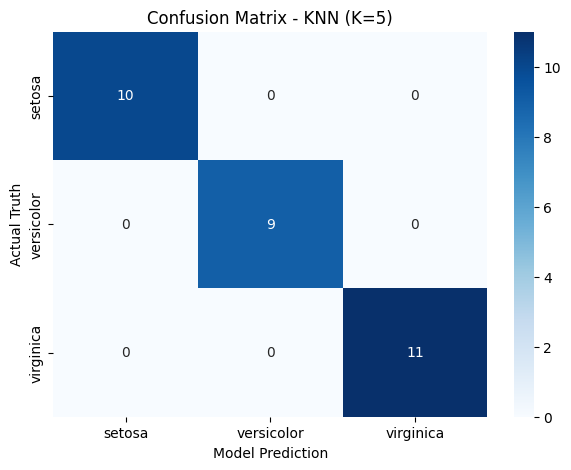


--- Model Evaluation Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. The Diagnostic Tool: Confusion Matrix
cm = confusion_matrix(y_test, predictions)

# Let's visualize it properly
plt.figure(figsize=(7,5))
# Note: make sure 'iris.target_names' is defined from your earlier cells
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', 
            xticklabels=['setosa', 'versicolor', 'virginica'], 
            yticklabels=['setosa', 'versicolor', 'virginica'])
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.title('Confusion Matrix - KNN (K=5)')
plt.show()

# 2. Strategic Trade-offs: Precision, Recall, and F1 Score
print("\n--- Model Evaluation Report ---")
print(classification_report(y_test, predictions, target_names=['setosa', 'versicolor', 'virginica']))